# 第36课 · 先学会温柔，再学会分析——窗函数（window function）驯服频谱泄漏，Hann / Hamming / Blackman 对决

**今日目标**：先看懂频谱泄漏是怎么来的，再学会用对比表读出 Rectangular / Hann / Hamming / Blackman 的边缘差异。

> **主路径**：用 **Hann** 讲透「为什么要温柔」→ 再扫表对比其余三窗（不必每个窗推一遍公式）。下一站 STFT（L43）每帧都会乘窗。

**要点**：矩形窗旁瓣（sidelobe）泄漏从哪来；平滑窗如何压泄漏。

**为什么对 Aurora 重要**：STFT 每帧默认 Hann；`windows.py` 对应本课。选错窗，泄漏会污染 Mel 特征。

← **上一课**　[L35 · 欧拉公式遇见 FFT](L35_euler_fft.ipynb)

> 上节课学习了 **欧拉公式遇见 FFT**：e^{-2πikn/N} 是什么，旋转因子可视化。  
> 本课将探讨 **窗函数原理**。

## 本课剧情：为什么录音要"淡入淡出"？

混音师在剪辑一段录音时，常常会在片段两端做"淡入淡出"（fade in / fade out）——音量从 0 缓慢升到最大，再缓慢降回 0。

这不只是审美，而是**数学必要性**：如果直接截取一段信号，边缘处幅值会突然从某个值跳到 0——相当于乘了一个矩形函数。FFT 不知道"这是截取边界"，会把这个跳变当成真实的高频成分，在频谱上产生**旁瓣（sidelobe）污染**。

### 为什么边界的硬跳变会产生高频？

想象一根琴弦，你本来在弹一个 440 Hz 的纯净 A 音。但如果你突然用手指死死掐住琴弦，会产生什么？不是安静，而是一声刺耳的噪声——包含许多高频成分。数学上，这就是**频谱泄漏**：时域的不连续边界对应频域的高频污染。具体地说：

- **矩形截断** = 信号 × 矩形函数（两端值 1，外面 0）
- 在频域里，这等价于原频谱与 **sinc 函数**做卷积
- sinc 的副瓣高度约 -13 dB（即 1/20 的主峰强度），造成"旁瓣泄漏"

**"卷积"到底是什么？（先用三句话建立直觉，不追求严格定义）** 你可以把卷积想象成拿一把"模糊刷"去涂抹另一个函数：把 sinc 这个形状（中间一个大鼓包，两侧一串越来越矮的小波纹）放到频谱上原本又窄又尖的每一根谱线上，让那根谱线"晕开"成 sinc 的样子——原来干净的一个尖峰，晕开后中心还在，但两侧多出了一串越来越矮的"余晖"，这些余晖就是旁瓣。矩形函数的傅里叶变换之所以恰好长成 sinc 的样子，源于时域和频域的一条对偶关系：**时域越"方越硬"（边缘越突兀），频域就越"散得开"（旁瓣越多）**。这条关系的完整代数推导（矩形函数的傅里叶变换为什么恰好是 sinc）会在 **L37 手推 DFT 公式**、以及 L38-L39 讲 FFT 时给出——这里你只需要先记住这条对应关系就够了：**时域乘矩形窗 ⇔ 频域和 sinc 卷积 ⇔ 旁瓣泄漏**。

**分贝（dB）是什么**：它是一个对数刻度，衡量幅度比：  
$$\text{dB} = 20 \log_{10}(\text{幅度比})$$  
- 比值为 1 时，dB = 0
- 比值为 10 时，dB = 20
- 比值为 0.1 时，dB = -20  

表中"-13 dB"表示"旁瓣幅度是主峰的 1/4.5 倍"；"-58 dB"表示"旁瓣只有主峰的 1/1000"。dB 越负，旁瓣被压低得越彻底。

**窗函数（window function）**解决这个问题：一串与信号等长的权重，两端接近 0、中间接近 1。信号逐点乘上这些权重，边缘被"温柔地压低"，FFT 看到的就是平滑过渡，而非突变——从而大幅减少旁瓣污染。

三种常用窗：

| 窗 | 公式核心 | 旁瓣抑制 | 主瓣宽度 |
|---|---|---|---|
| **矩形（Rectangular）** | w[k]=1 | 差（-13 dB） | 最窄 |
| **Hann** | 0.5·(1-cos(2πk/N)) | 好（-31 dB） | 中等 |
| **Hamming** | 0.54-0.46·cos(2πk/N) | 较好（-41 dB） | 中等 |
| **Blackman** | 0.42-0.5·cos+0.08·cos(4π) | 很好（-58 dB） | 最宽 |

> 注：表中分母用 N（**periodic** 约定，Aurora/STFT 默认）。NumPy 的 `np.hanning`/`np.hamming` 用 **symmetric** 约定（分母 N−1），本课稍后的手算表和白板挑战用的正是 symmetric 版——两种约定的差别见下文「Periodic 与 Symmetric」一节。

本节任务：实现 `describe_window(name, w)`，读取窗数组的首尾值和峰值位置，验证三种窗的形状差异。

## 1. 先看窗函数本身

窗函数是一串和信号等长的权重。把信号逐点乘上这些权重，片段边缘会被压低，中间部分保留得更多。

- Rectangular：所有位置都是 1，相当于不处理边缘。
- Hann / Blackman：两端接近 0，边缘最柔和。
- Hamming：两端不为 0，保留一点边缘能量。

用四个数字就能描述一个窗的边界行为：首端值 `w[0]`、尾端值 `w[-1]`、峰值 `w.max()`、峰值位置 `argmax(w)`。Hann / Blackman 首尾接近 0，把边缘压至几乎为零；Hamming 首尾约 0.08，保留少量边缘能量；Rectangular 首尾为 1，完全不做压制。边界值越接近 0，频谱旁瓣越低，但主瓣（main lobe）越宽——旁瓣抑制和频谱分辨率之间躲不开的权衡。

### Hamming 为什么比 Hann"更强"？

这里有个反直觉的地方：Hann 的首尾为 0（完全压制边缘），而 Hamming 的首尾约 0.08（保留边缘能量）。但表格上 Hamming 的旁瓣（-41 dB）比 Hann（-31 dB）更低！

原因在于**频域中 sinc 旁瓣的构造**。Hann 的"完全压制"（两端为 0）会在频域引起某些副作用：边缘处仍然有轻微的不连续性（从非零值跳到 0）。而 Hamming 的"保留一点能量"设计（尾端 0.08）是经过精心计算的，使得这个 0.08 恰好与中间部分的频谱形成**相消干涉**（destructive interference）——不同频率的旁瓣成分互相抵消。这像调音时的"消噪耳机"原理：通过加一个反向的波形来消掉不想要的声音。

**系数 0.54 和 0.46 的由来**：这不是随便选的。它们来自数值优化：研究者用计算机搜索，找到最佳的两个常数，使得频域旁瓣最低。结果就是 0.54 和 0.46（正好相加为 1）。Hann 的对应系数是 0.5 和 0.5，是特殊情况。

**旁瓣和主瓣的权衡根源**：这不是我们的设计缺陷，而是傅里叶分析的**根本限制**。在时域和频域之间，窄和宽是相对的——你不能同时让信号在两个域都很"窄"。这就像海森堡不确定性原理：位置和动量不能同时精确。在窗函数中：

- 在**时域压得越狠**（边缘更接近 0）→ 在**频域里形成更复杂的形状**（主瓣变宽，副瓣分散增加）
- 只能选择你更在乎的方面：优先压旁瓣（Hamming / Blackman），还是优先保持主瓣窄（Rectangular）？

STFT 用 Hann 窗是折中方案：旁瓣压制中等（-31 dB，足够好），主瓣宽度也中等，计算也简单。

## 实验入口：把声音拆成可观察的数组

这里用64个采样点、采样率（sample rate，sr）200 Hz的短正弦，让 `signal * window` 的结果可以直接打印，便于确认边缘值是否被压低。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np
from aurora.audio import hann, hamming, blackman
print('就绪')

就绪


## 动手观察：序列怎样一步步变成信号

改 `sample_rate` 或 `duration`，观察采样点数 `N = int(sample_rate * duration)` 如何变化；下一格的窗权重数组长度将与 `N` 保持一致。

In [3]:
import numpy as np

sample_rate = 8
duration = 1.0
freq = 2.0
N = round(duration * sample_rate)
n = np.arange(N)
t = n / sample_rate
angle = 2 * np.pi * freq * t
wave = np.sin(angle)

print('N =', N)
print('采样点编号 n =', n)
print('时间轴 t =', np.round(t, 3))
print('角度 angle =', np.round(angle, 3))
print('sin(angle) =', np.round(wave, 3))


N = 8
采样点编号 n = [0 1 2 3 4 5 6 7]
时间轴 t = [0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875]
角度 angle = [ 0.     1.571  3.142  4.712  6.283  7.854  9.425 10.996]
sin(angle) = [ 0.  1.  0. -1. -0.  1.  0. -1.]


## 代码实验：比较几种窗函数的边缘

打印 `w[:3]` 和 `w[-3:]`，直接看矩形窗边缘值为 1.0 而 Hann 窗边缘接近 0 这一差异。

### Periodic 与 Symmetric Hann：Aurora 和 NumPy 的差异

同一个 Hann 公式有两种常见约定：

| | `np.hanning(N)` (symmetric) | `aurora.hann(N)` (periodic / DFT-even) |
|---|---|---|
| 公式 | `w[n] = 0.5(1 - cos(2πn/(N-1)))` | `w[n] = 0.5(1 - cos(2πn/N))` |
| 首端 `w[0]` | 0 | 0 |
| 尾端 `w[-1]` | ≈ 0 | ≈ 0.095（N=10）/ 0.0024（N=64） |
| 峰值位置 | `N//2 - 1` = 4（N=10） | `N//2` = 5（N=10） |
| 适用场景 | FIR 滤波器设计 | STFT 无缝拼帧（Aurora 默认）|

**为什么会有两种公式？**

简单想象：当你把信号分成重叠的帧（overlap）来做 STFT 时，相邻两帧会在重叠区域相加。如果窗的尾端 `w[-1]` 完全为 0（symmetric），那两帧相加时，重叠处会"断层"——能量在边界处丢失。但如果尾端不为 0（periodic），相邻帧在重叠处的加权和就能保持恒定，形成"无缝拼接"。这对 STFT 的频率分析精度很重要。

**具体例子**：N=10 时，两种公式的对比
```
Symmetric (NumPy): k=0,1,2,...,9 → 分母=N-1=9
  w[0] = 0.5(1-cos(0))       = 0
  w[1] = 0.5(1-cos(2π/9))    ≈ 0.0955
  w[4] = 0.5(1-cos(8π/9))    ≈ 0.9045（峰值）
  w[9] = 0.5(1-cos(18π/9))   = 0

Periodic (Aurora): k=0,1,2,...,9 → 分母=N=10
  w[0] = 0.5(1-cos(0))       = 0
  w[1] = 0.5(1-cos(2π/10))   ≈ 0.1102
  w[5] = 0.5(1-cos(10π/10))  = 1.0（峰值在中间）
  w[9] = 0.5(1-cos(18π/10))  ≈ 0.0955（不为0！）
```

**关键区别**：symmetric 的 w[9]=0 使得窗"突然截断"，像之前说的矩形截断问题；periodic 的 w[9]≈0.095 让窗"缓缓下台"，与相邻帧平滑衔接。这就是为什么 STFT 要用 periodic 版本。

本课的代码实验（cell 9、18、26）用 `np.hanning`/`np.hamming` 演示对称窗的直观形状；Aurora 源码（`aurora.audio.windows`）和练习（cell 14）使用 `periodic=True` 版本。两套数值不同，但物理意义相同——都是压低边缘能量。

In [4]:
import numpy as np

N = 16
windows = {
    'rectangular': np.ones(N),
    'hann': np.hanning(N),
    'hamming': np.hamming(N),
}

for name, w in windows.items():
    print(name)
    print('  first 5 =', np.round(w[:5], 3))
    print('  last  5 =', np.round(w[-5:], 3))


rectangular
  first 5 = [1. 1. 1. 1. 1.]
  last  5 = [1. 1. 1. 1. 1.]
hann
  first 5 = [0.    0.043 0.165 0.345 0.552]
  last  5 = [0.552 0.345 0.165 0.043 0.   ]
hamming
  first 5 = [0.08  0.12  0.232 0.398 0.588]
  last  5 = [0.588 0.398 0.232 0.12  0.08 ]


## 2. ✏️ 实现 `describe_window(name, w)`

**手算 Hann 窗（N=8）的关键点**：

公式（**symmetric** 约定，分母 N−1，同 `np.hanning`；引言表写的是 periodic 版，分母 N）：`w[k] = 0.5 · (1 - cos(2π·k / (N-1)))`，k = 0, 1, ..., N-1

| k | 角度 2πk/7 | cos(...) | w[k] |
|---|---|---|---|
| 0 | 0 | 1 | **0**（左端=0） |
| 1 | 2π/7 | 0.6235 | 0.1883 |
| 3 | 6π/7 | -0.9009 | **0.9505**（接近峰值） |
| 7 | 2π | 1 | **0**（右端=0） |

**规律**：
- 对称窗：`w[0] ≈ w[-1] ≈ 0`，峰值在 `N//2 - 1` 附近
- Hamming：首尾不为 0（≈ 0.08），保留少量边缘能量
- 矩形窗：`w[0] = w[-1] = 1.0`（无淡化）

`describe_window` 的返回值应是一个四元组 `(first, last, peak, peak_idx)`，依次为：
- `first`: `w[0]`
- `last`: `w[-1]`
- `peak`: `w.max()`
- `peak_idx`: `int(np.argmax(w))` ← `argmax` 是什么？它返回**最大值所在的位置的下标**。比如 `np.argmax([0.5, 0.9, 0.3])` 返回 1（因为最大值 0.9 在位置 1）

### 写代码前，先把变量表补完整

写 `describe_window` 前明确三件事：
- 输入：`w`（shape `(N,)` 的窗权重数组，值域 0~1）
- 关键步骤（记住这四个）：
  1. `w[0]` —— 首端值（矩形1，Hann/Blackman接近0，Hamming≈0.08）
  2. `w[-1]` —— 尾端值（矩形1，Hann尾端=0，Blackman接近0，Hamming≈0.08；但periodic Hann/Hamming尾端可能不为0）
  3. `w.max()` —— 峰值（所有窗的峰值都接近或等于1）
  4. `int(np.argmax(w))` —— 峰值所在的下标位置。`argmax` 返回最大值的位置：`np.argmax([0.1, 0.9, 0.5])` → 1
- 返回：四元组 `(first, last, peak, peak_idx)`，依次是首端值、尾端值、峰值、峰值位置索引

In [5]:
def describe_window(name, w):
    """
    描述一个窗函数的关键性质。
    
    输入：
      name: 窗的名字（字符串），用于打印
      w: 窗权重数组，shape (N,)，值域 [0, 1]
    
    返回：四元组 (first, last, peak, peak_idx)
      first: w[0]，首端值
      last: w[-1]，尾端值
      peak: w.max()，峰值
      peak_idx: 峰值位置（整数下标）
    
    实现步骤：
      1. 从 w 读取 w[0]、w[-1]、w.max()
      2. 用 np.argmax(w) 找峰值位置，记得转换成 int
      3. 打印这四个值（便于调试）
      4. 返回四元组
    """
    # ✏️ TODO: 替换下面这行，按上面的步骤实现
    print(name, '窗数组长度', len(w))
    raise NotImplementedError("TODO: 提取首/尾/峰/峰值位置，返回四元组 (first, last, peak, peak_idx)")

## 3. 在三种窗上调用 + 自动检查

In [6]:
N = 64
windows = {'Hann': hann(N), 'Hamming': hamming(N), 'Blackman': blackman(N)}
all_ok = True
for name, w in windows.items():
    assert w.shape[0] == N
    try:
        result = describe_window(name, w)
    except (NotImplementedError, TypeError):
        print('⬜ 未实现')
        all_ok = False
        break
    if result is None:
        print('⬜ 未实现')
        all_ok = False
        break
    first, last, peak, peak_idx = result
    assert abs(first - w[0]) < 1e-9, f'{name}: first 值不对'
    assert abs(last - w[-1]) < 1e-9, f'{name}: last 值不对'
    assert abs(peak - w.max()) < 1e-9, f'{name}: peak 值不对'
    assert peak_idx == int(np.argmax(w)), f'{name}: peak_idx 不对'

if all_ok:
    assert abs(hann(N)[0]) < 1e-9, 'Hann 窗首端应为 0（periodic DFT-even 窗；尾端 w[-1] ≈ 0.0024 for N=64，不为 0）'
    print('\n✅ 窗函数性质核对完毕。')

Hann 窗数组长度 64
⬜ 未实现


## 4. 画出三种窗对比

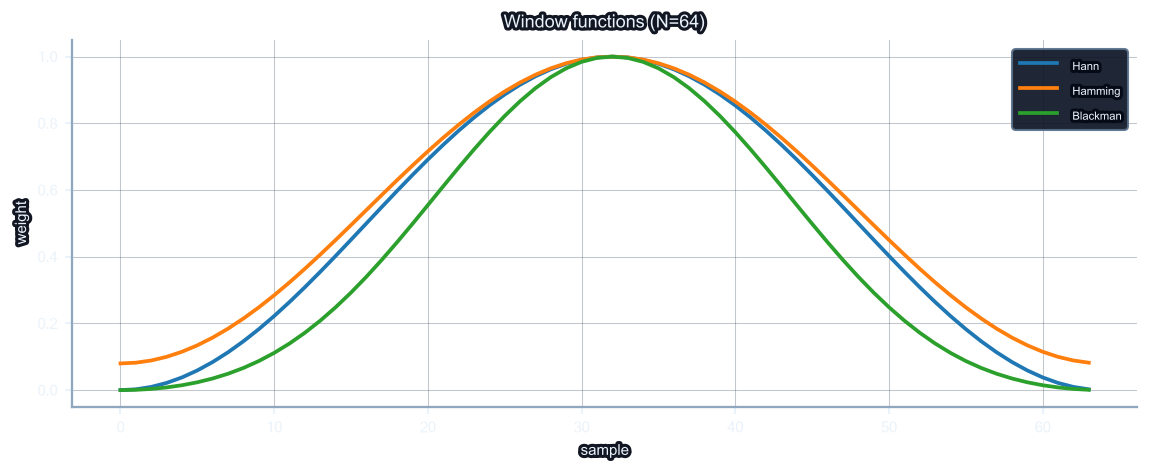

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 3.5))
for name, w in windows.items():
    plt.plot(w, label=name)
plt.title(f'Window functions (N={N})')
plt.xlabel('sample'); plt.ylabel('weight')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 4.1 加窗（windowing）前后：同一段信号，不同边缘

下面保留同一段正弦，只改变窗。先看时域（time domain）边缘，再看频域（frequency domain）里主峰旁边的能量。


## 4.0 加窗对 STFT 分帧的具体影响

前面说 Aurora STFT 在每一帧都乘以 Hann 窗。具体怎么做的？

想象把一段长音频分成重叠的短帧，每帧 256 个样本，相邻帧之间 overlap 128 个点：

```
原始信号：[===帧1===|====帧2====|====帧3====| ...]
帧长度：   |--------|
Overlap:     |------|（128个样本）
```

对每一帧做加窗：

```
帧1 → 乘以 Hann 窗 w → xw1 = 帧1 * w
帧2 → 乘以 Hann 窗 w → xw2 = 帧2 * w
...
```

**能量守恒**（Constant Overlap-Add, COLA）：
如果用 periodic Hann（不是 symmetric），相邻帧的重叠部分相加时，总能量会保持恒定。也就是说：
- xw1 的后 128 点 + xw2 的前 128 点 = 常数（不会因为加窗而衰减或增强）

这叫"无缝拼接"。反过来，如果用 symmetric Hann（尾端为 0），重叠处会有"能量缺口"，整个信号经过 STFT→ISTFT 后会被削弱——这就是为什么 STFT 要用 periodic 版本。

**具体数值验证**下面会做：用两种窗和两种帧重叠，对比加窗前后的能量变化。

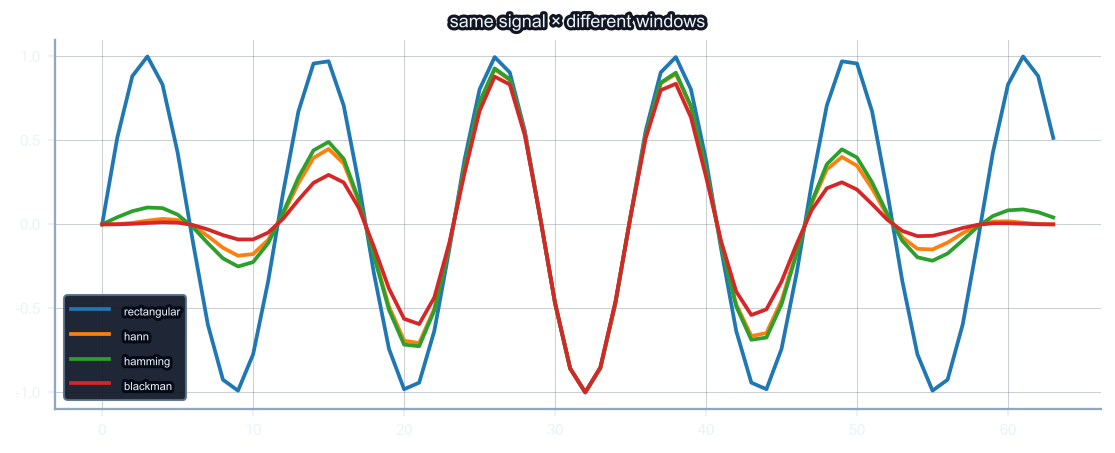

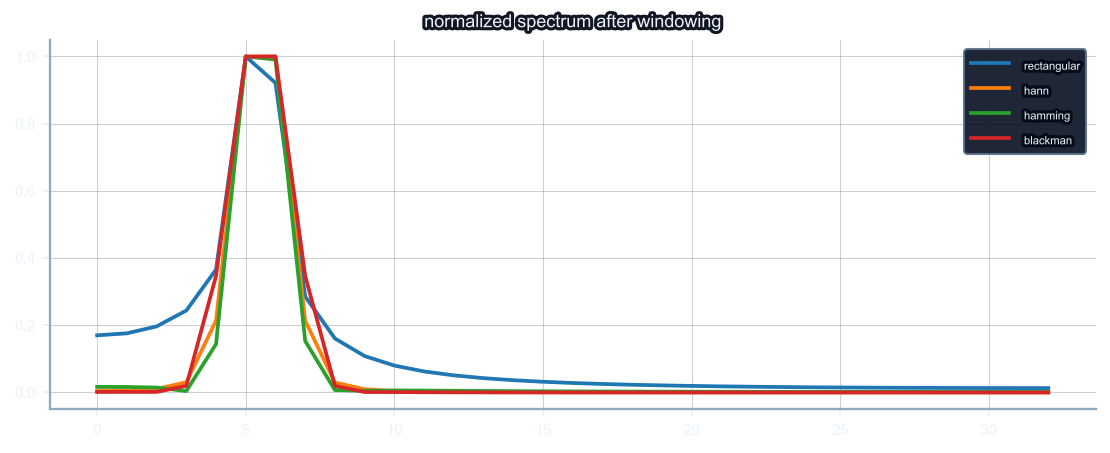

In [8]:
import numpy as np, matplotlib.pyplot as plt

N = 64
n = np.arange(N)
signal = np.sin(2*np.pi*5.5*n/N)  # 非整数周期，边缘会接不上
windows = {
    'rectangular': np.ones(N),
    'hann': np.hanning(N),
    'hamming': np.hamming(N),
    'blackman': np.blackman(N),  # 增补：与标题一致
}

plt.figure(figsize=(9, 3.2))
for name, w in windows.items():
    plt.plot(signal * w, label=name)
plt.title('same signal × different windows')
plt.legend(); plt.grid(True, alpha=.25); plt.show()

plt.figure(figsize=(9, 3.2))
for name, w in windows.items():
    spectrum = np.abs(np.fft.rfft(signal * w))
    plt.plot(spectrum / spectrum.max(), label=name)
plt.title('normalized spectrum after windowing')
plt.legend(); plt.grid(True, alpha=.25); plt.show()


### 插播：跳变到底是怎么"需要"高频正弦波的？

上面这段代码里，`signal = np.sin(2*np.pi*5.5*n/N)` 故意选了一个**非整数**周期数（5.5 个周期，不是 5 或 6）。这是关键：FFT 把窗口里的这 64 个点当成"无限重复播放的一段循环"来处理——如果把这一小段掐头去尾、首尾相连、反复播放，5.5 个周期收尾的地方，波形高度对不上上一轮的开头，会出现一个"台阶"（跳变）。整数周期（比如 6.0）则刚好首尾拼接得上，没有台阶。

那这个台阶在频谱里意味着什么？换个角度想：假如你只有一堆"整数周期"的纯正弦波（1 个周期、2 个周期、3 个周期……），想叠加出一个带台阶的波形，你需要多少根正弦波来帮忙？答案是：需要很多很多根，而且**频率越高的那些正弦波，负责的正是台阶附近那个又窄又陡的转折**——转折越尖锐，就越依赖越高频的成分去"描边"。这就是矩形截断（不加窗）会在频谱里制造大量高频旁瓣的根本原因：边缘的不连续本身就"天生需要"高频正弦波去拼凑。

为了让这件事看得更明白，下面换一个更极端也更好画的例子——理想方波（square wave，从 -1 突然跳到 +1，跳变比上面的正弦截断更夸张）——直接看"用正弦波叠加画出一个跳变"具体长什么样。

只用 1 个正弦波：只能画出一条圆滑的正弦曲线，完全画不出直角跳变。
叠加到 21 个谐波：跳变附近已经陡峭很多，但边缘仍有一点"抖动/过冲"——
这个现象叫吉布斯现象（Gibbs phenomenon），即使叠加无穷多个正弦波，这点抖动也不会消失，只会越挤越窄。
这正是矩形窗旁瓣的来源：跳变天生需要无穷多个高频正弦波才能精确重建；
FFT 只能用有限个频点去凑，凑不齐、又消不干净的那部分高频能量，就变成了频谱上的旁瓣。
L37 手推 DFT 公式时，会给出这背后严格的系数推导（傅里叶级数系数公式）。


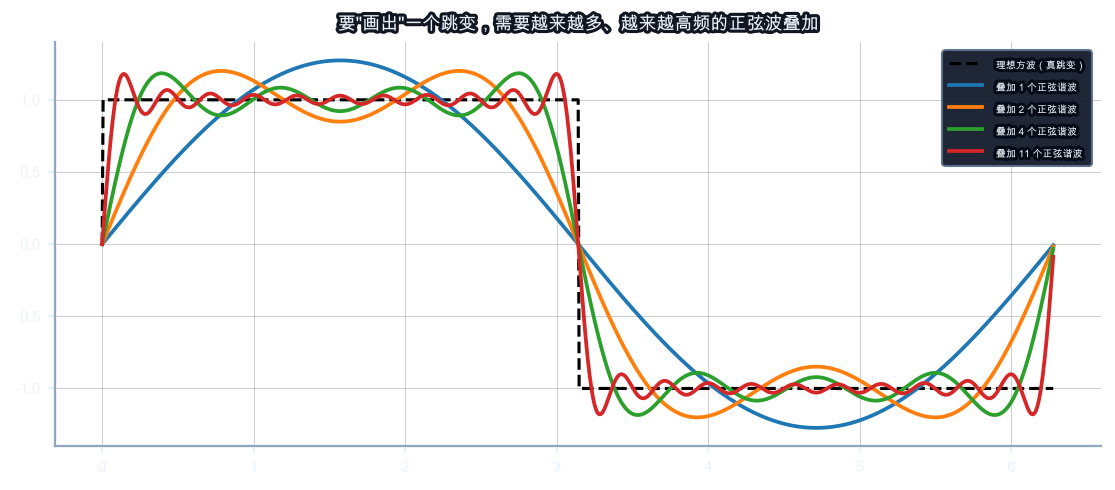

In [9]:
# 演示：要"画出"一个跳变（jump discontinuity），需要多少根正弦波叠加？
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2*np.pi, 1000, endpoint=False)
square = np.sign(np.sin(x))  # 理想方波：在 0 和 pi 处突然跳变，是"跳变"的极端例子

plt.figure(figsize=(9, 3.5))
plt.plot(x, square, 'k--', label='理想方波（真跳变）', linewidth=1.5)
for n_harmonics in [1, 3, 7, 21]:
    approx = np.zeros_like(x)
    for k in range(1, n_harmonics + 1, 2):  # 方波的傅里叶级数只需要奇次谐波 1,3,5,...
        approx += (4 / (np.pi * k)) * np.sin(k * x)
    plt.plot(x, approx, label=f'叠加 {(n_harmonics + 1) // 2} 个正弦谐波')
plt.title('要"画出"一个跳变，需要越来越多、越来越高频的正弦波叠加')
plt.legend(fontsize=8); plt.grid(True, alpha=.25); plt.show()

print('只用 1 个正弦波：只能画出一条圆滑的正弦曲线，完全画不出直角跳变。')
print('叠加到 21 个谐波：跳变附近已经陡峭很多，但边缘仍有一点"抖动/过冲"——')
print('这个现象叫吉布斯现象（Gibbs phenomenon），即使叠加无穷多个正弦波，这点抖动也不会消失，只会越挤越窄。')
print('这正是矩形窗旁瓣的来源：跳变天生需要无穷多个高频正弦波才能精确重建；')
print('FFT 只能用有限个频点去凑，凑不齐、又消不干净的那部分高频能量，就变成了频谱上的旁瓣。')
print('L37 手推 DFT 公式时，会给出这背后严格的系数推导（傅里叶级数系数公式）。')


## 5. 源文件阅读：把概念映射回 Aurora

完成窗函数实验后，再打开这两个文件：

- `src/aurora/audio/io.py`：`sine` / `chirp` / `read_wav` / `write_wav`
- `src/aurora/audio/windows.py`：`hann` / `hamming` / `blackman`

阅读时只对照三件事：函数输入、返回数组、数组长度。


## 🎨 图示：从窗 → STFT 分帧 → 频谱 → mel

把后面 L37-L47 要做的事先看一眼，统一观感。

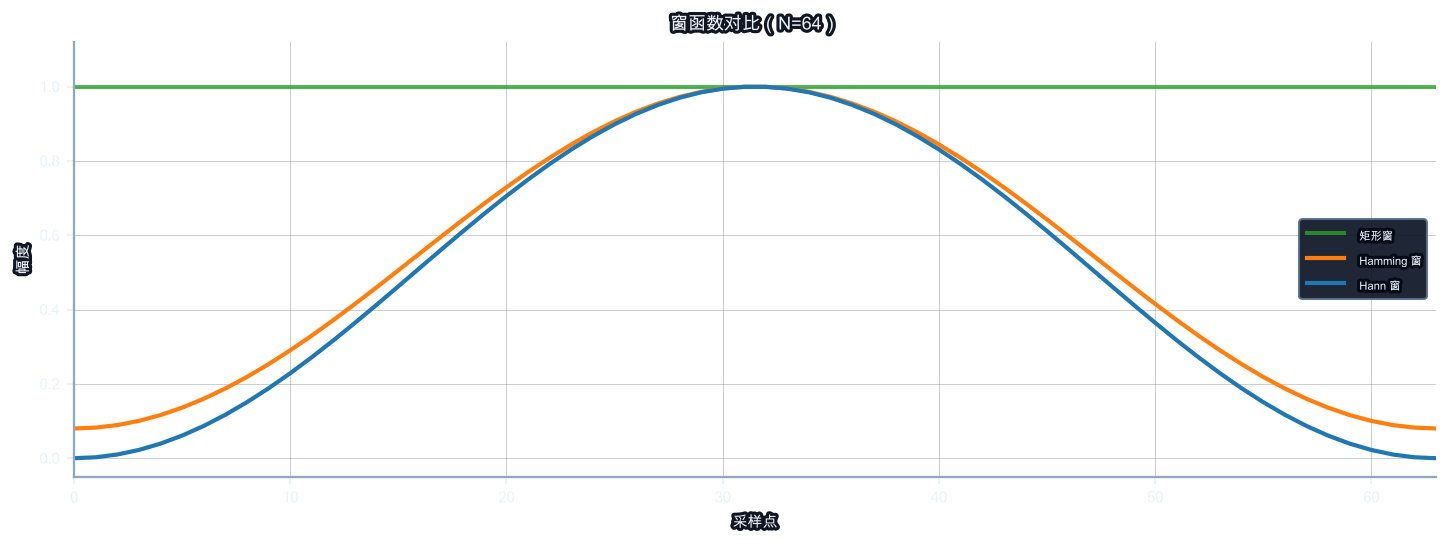

In [10]:
from aurora.audio import sine
import aurora.aviz as aviz; aviz.style()
long = sine(220.0, duration=0.05, sample_rate=16000)
aviz.windows_overlay(64);

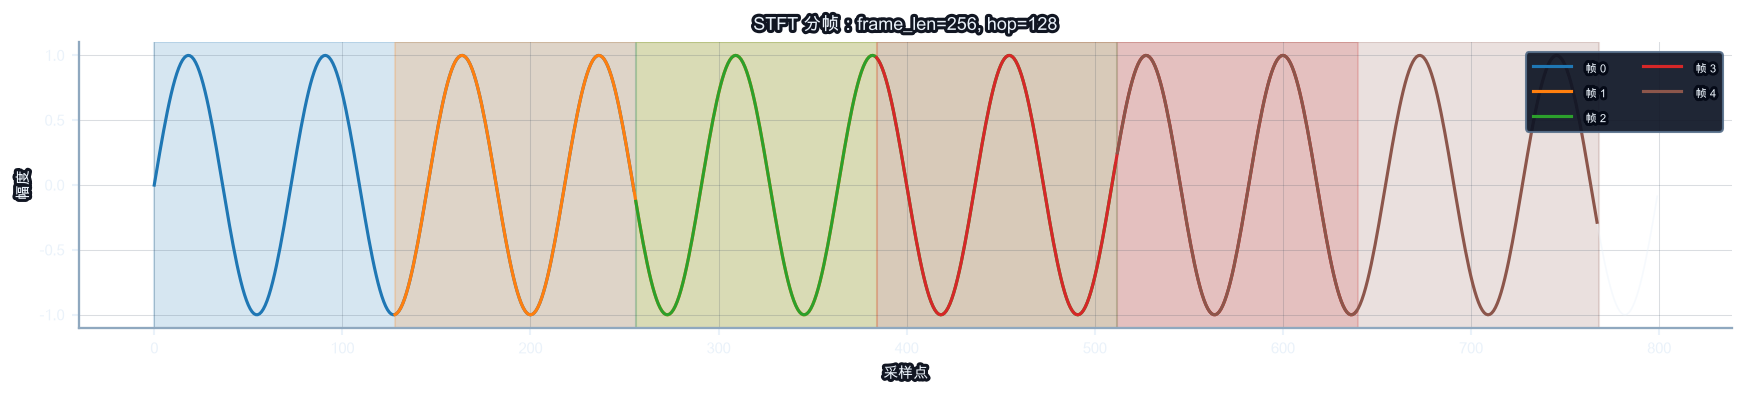

In [11]:
aviz.framing(long, frame_len=256, hop=128, n_frames=5);   # STFT 分帧

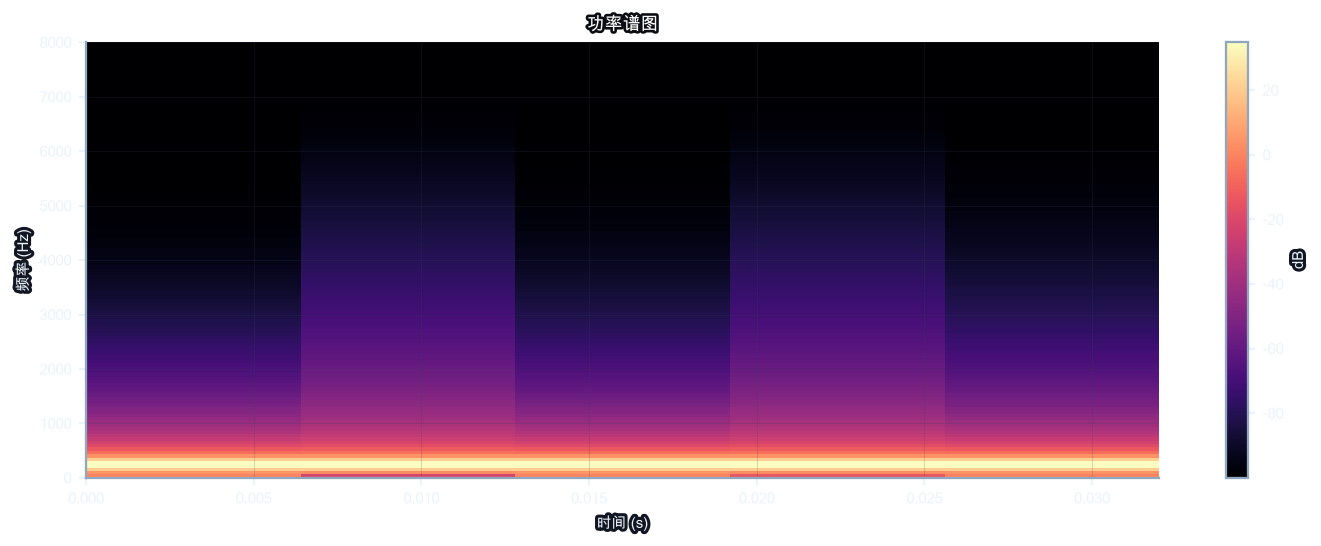

In [12]:
aviz.spectrogram(long);                                   # 功率谱图

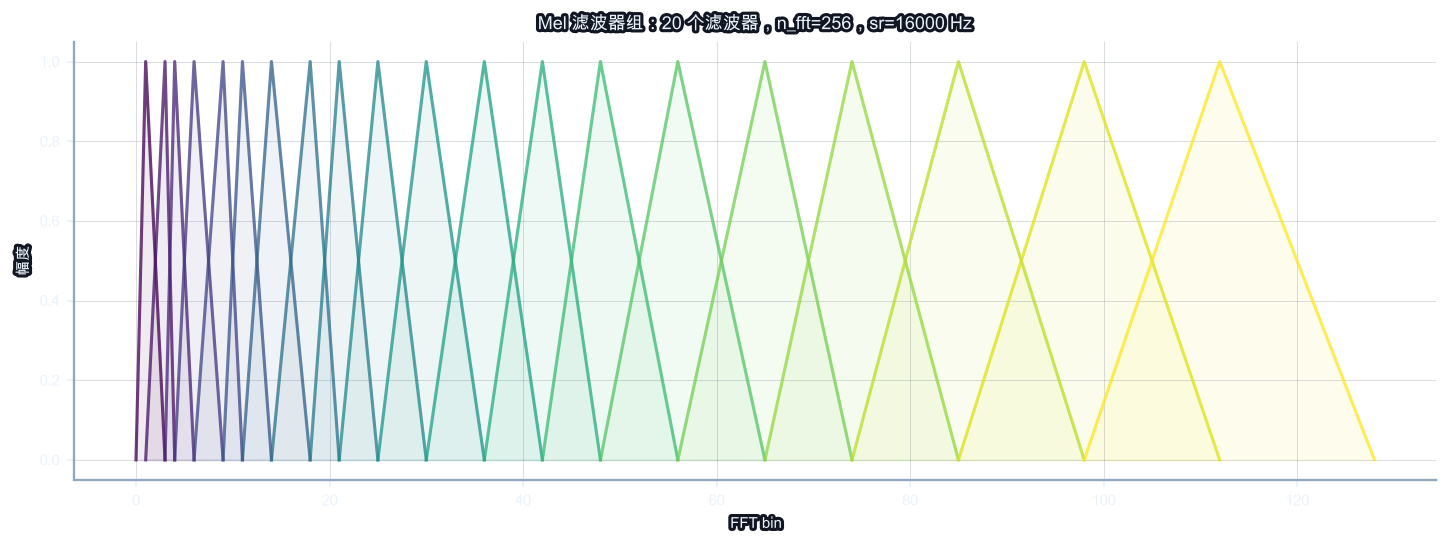

In [13]:
aviz.mel_filterbank_plot(20, 256, 16000);                 # mel 滤波器组=矩阵

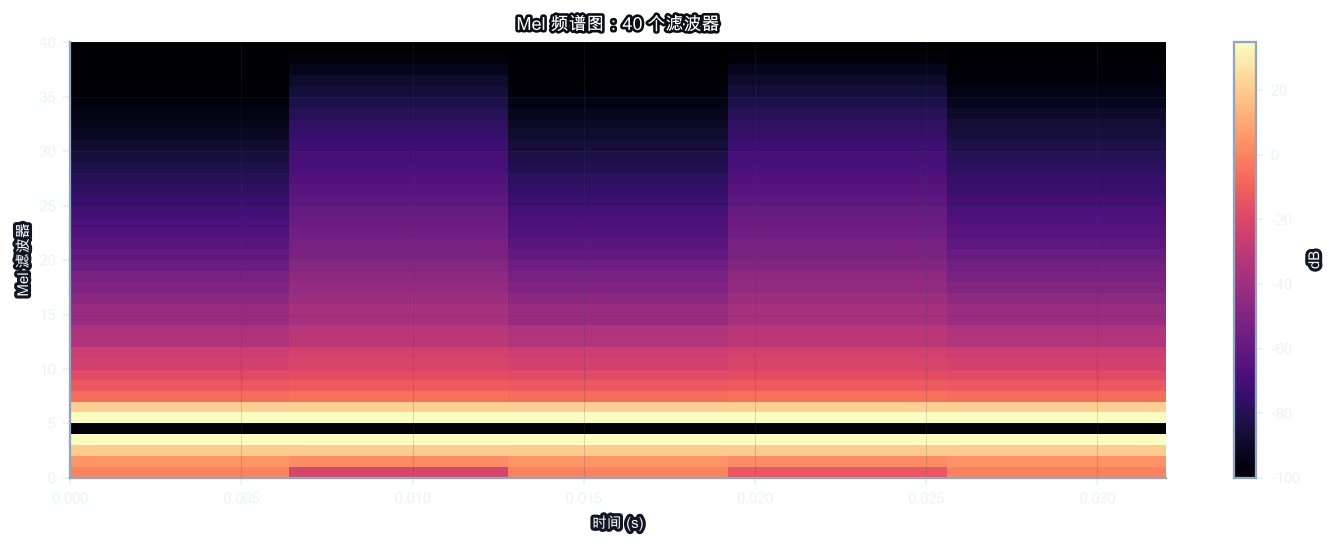

In [14]:
aviz.mel_spectrogram_plot(long, 16000, 40);               # mel 频谱图

In [15]:
N = 16
signal = np.ones(N)
for window_name, window in [('rect', np.ones(N)), ('hann', np.hanning(N)), ('hamming', np.hamming(N)), ('blackman', np.blackman(N))]:
    shaped = signal * window
    edge_energy = shaped[0]**2 + shaped[-1]**2
    print(f'{window_name:7s} | 边缘值=({shaped[0]:.3f}, {shaped[-1]:.3f}) | 边缘能量={edge_energy:.3f}')


rect    | 边缘值=(1.000, 1.000) | 边缘能量=2.000
hann    | 边缘值=(0.000, 0.000) | 边缘能量=0.000
hamming | 边缘值=(0.080, 0.080) | 边缘能量=0.013
blackman | 边缘值=(-0.000, -0.000) | 边缘能量=0.000


In [16]:
# 演示：COLA 条件验证（能量守恒）
# 当用 periodic Hann 加窗，且 overlap = 50%（hop_size = N//2）时，加窗后的帧相加应该保持恒定

N = 64
from aurora.audio import hann as aurora_hann
from numpy import hanning

# 用 Aurora 的 periodic Hann（默认参数 periodic=True）
w_periodic = aurora_hann(N)
# 用 NumPy 的 symmetric Hann（默认）
w_symmetric = hanning(N)

# 模拟两个重叠的帧，overlap = 50%
hop = N // 2  # 50% overlap
frame1 = np.ones(N)  # 简化：都是 1
frame2 = np.ones(N)

# 加窗后的帧
xw1_periodic = frame1 * w_periodic
xw2_periodic = frame2 * w_periodic

xw1_symmetric = frame1 * w_symmetric
xw2_symmetric = frame2 * w_symmetric

# 在重叠区域相加（frame1 的后 hop 个点 + frame2 的前 hop 个点）
overlap_sum_periodic = xw1_periodic[hop:] + xw2_periodic[:hop]
overlap_sum_symmetric = xw1_symmetric[hop:] + xw2_symmetric[:hop]

print("Periodic Hann (Aurora)：")
print(f"  前 3 个重叠值：{np.round(overlap_sum_periodic[:3], 4)}")
print(f"  后 3 个重叠值：{np.round(overlap_sum_periodic[-3:], 4)}")
print(f"  是否接近恒定？ {np.allclose(overlap_sum_periodic, overlap_sum_periodic[0], atol=0.01)}")

print("\nSymmetric Hann (NumPy)：")
print(f"  前 3 个重叠值：{np.round(overlap_sum_symmetric[:3], 4)}")
print(f"  后 3 个重叠值：{np.round(overlap_sum_symmetric[-3:], 4)}")
print(f"  是否接近恒定？ {np.allclose(overlap_sum_symmetric, overlap_sum_symmetric[0], atol=0.01)}")
print(f"  （注：symmetric Hann 尾端为 0，重叠区后半边有缺口）")

print("\n💡 这就是为什么 STFT 必须用 periodic 版本：能量守恒 → 频率分析精度有保证。")

Periodic Hann (Aurora)：
  前 3 个重叠值：[1. 1. 1.]
  后 3 个重叠值：[1. 1. 1.]
  是否接近恒定？ True

Symmetric Hann (NumPy)：
  前 3 个重叠值：[0.9994 0.9969 0.9945]
  后 3 个重叠值：[0.9945 0.9969 0.9994]
  是否接近恒定？ False
  （注：symmetric Hann 尾端为 0，重叠区后半边有缺口）

💡 这就是为什么 STFT 必须用 periodic 版本：能量守恒 → 频率分析精度有保证。


## 参数实验：旁瓣高度直接对比

对同一段正弦信号（频率恰好在两个 FFT 频点之间），分别用 Rectangular 和 Hann 加窗后做 FFT，观察 Rectangular 的频谱旁瓣高出主瓣约 13 dB，Hann 的旁瓣低约 31 dB。差距来自边缘处理：Rectangular 的硬截断制造虚假高频，Hann 的平滑过渡大幅压制旁瓣。这就是 STFT 几乎总是用 Hann 窗的原因。

进一步实验：把 `signal = np.sin(2*np.pi*5.5*n/N)` 中的 `5.5` 改成整数（如 `6.0`），矩形窗的旁瓣会消失——频率为整数倍时，FFT 周期边界处信号恰好连续，边缘跳变为零，旁瓣污染也随之消失。

## 附录 A · 进入 L37 前：分治思维 5 分钟预习（非新课）

你已经完成了窗函数这一步：

```text
原始片段 x  ×  窗权重 w  =  加窗后的片段 xw
```

下一课 L37 会问一个新问题：

> `xw` 里面到底混着哪些频率？

DFT 的暴力做法很直接：拿每一个候选频率去和 `xw` 对齐比较，
算出“这个频率成分有多强”。公式会写成：

```text
X[k] = Σ x[n] · e^{-2πikn/N}
```

你现在不需要推导它，只要先记住三件事：

1. L36 的输出是一个数组：`xw = x * window`
2. L37 会用双重循环暴力计算所有频率成分
3. L38-L39 才会问：能不能不要每个频率都从头算一遍？

FFT 的分治直觉像“高塔二分找楼层”：
如果你每层都检查一次，复杂度很高；如果你能把问题不断拆成左右两半，
就可以少做大量重复工作。

在 FFT 里，“拆成两半”不是随便拆，而是拆成：

- 偶数下标样本：`x[0], x[2], x[4], ...`
- 奇数下标样本：`x[1], x[3], x[5], ...`

L37 仍然只写暴力 DFT；L38 画蝶形图；L39 再写递归 FFT。
这节课只需要把入口记牢：

```text
signal → window → xw → DFT/FFT
```

如果卡住，回看：

- L06 / L35：旋转因子 `e^{-2πikn/N}`
- L07：复杂信号可以看成正弦叠加
- L21：DFT 可以写成矩阵乘法 `X = W @ x`


## 可选预热 · 用 `np.fft.fft` 看见 L37 的输入输出

下面这格不是让你提前学会 FFT，而是只看形状：

- 输入：长度为 `N` 的实数数组 `xw`
- 输出：长度仍为 `N` 的复数数组 `X`
- L37 会手写这个变换的暴力版本


In [17]:
import numpy as np

N = 8
n = np.arange(N)

# 一个完整周期的正弦波；L37 会把它拆成频率成分
x = np.sin(2 * np.pi * 1 * n / N)

# 这里用 symmetric Hann 只做直观演示；Aurora STFT 默认 periodic Hann
w = np.hanning(N)
xw = x * w

X = np.fft.fft(xw)

print("x  shape:", x.shape, "前4项:", np.round(x[:4], 3))
print("w  shape:", w.shape, "前4项:", np.round(w[:4], 3))
print("xw shape:", xw.shape, "前4项:", np.round(xw[:4], 3))
print("X  shape:", X.shape, "前4项:", np.round(X[:4], 3))

assert x.shape == w.shape == xw.shape == X.shape == (N,)
assert np.iscomplexobj(X), "FFT 输出应是复数：幅度 + 相位"

print("✅ 预热完成：L37 会解释 X[k] 是怎么算出来的")


x  shape: (8,) 前4项: [0.    0.707 1.    0.707]
w  shape: (8,) 前4项: [0.    0.188 0.611 0.95 ]
xw shape: (8,) 前4项: [0.    0.133 0.611 0.672]
X  shape: (8,) 前4项: [ 0.796+0.j    -0.075-1.675j -0.423+0.971j  0.075-0.075j]
✅ 预热完成：L37 会解释 X[k] 是怎么算出来的


## 本课收束

现在能用 `hann(N)`、`hamming(N)`、`blackman(N)` 生成窗权重，并把 `signal * w` 当作给边缘穿上的“软垫”。打印首尾值就能直接看见压低效果。这对应 Aurora STFT 流程的第一步：`aurora.audio.windows` 里的三个函数在 `stft` 分帧时被逐帧调用。下一节 L37（DFT 推导）进入 FFT 实现，今天的窗权重将作为 `xw = x * w` 直接输入离散傅里叶变换。

从下一课开始，问题从“怎样让边缘平滑”切换为：

> 这个加窗后的片段 `xw` 里有哪些频率？

L37 会先用双重循环手写 DFT；
L38 会把重复计算画成蝶形图；
L39 会把这个分治思路写成递归 FFT。

如果你能说清楚：

```text
signal → window → xw → DFT/FFT
```

就可以进入下一课。



In [18]:
# 小检查：从短序列开始，确认每一步输出
import numpy as np

sample_rate = 8
duration = 1.0
freq = 1.0
N = round(duration * sample_rate)
n = np.arange(N)
t = n / sample_rate
angle = 2 * np.pi * freq * t
x = np.sin(angle)

print('1) N 应该是多少？', N)
print('2) n 是采样点编号：', n)
print('3) t 是每个点的秒数：', np.round(t, 3))
print('4) angle 是每个点在圆上的角度：', np.round(angle, 3))
print('5) x 是最终波形：', np.round(x, 3))


1) N 应该是多少？ 8
2) n 是采样点编号： [0 1 2 3 4 5 6 7]
3) t 是每个点的秒数： [0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875]
4) angle 是每个点在圆上的角度： [0.    0.785 1.571 2.356 3.142 3.927 4.712 5.498]
5) x 是最终波形： [ 0.     0.707  1.     0.707  0.    -0.707 -1.    -0.707]


---
⬇️ **通关检验**：收束小结已读；请完成下方白板挑战后再勾选自评。


## ✏️ 白板挑战：窗函数手算（目标 10 分钟）

盖上屏幕，纸上作答：

**问 1**：Hann 窗（symmetric 约定）`w[k] = 0.5·(1-cos(2πk/(N-1)))`，N=4 时：
- w[0] = ?
- w[1] = ?（cos(2π/3) = -0.5）
- w[3] = ?（和 w[0] 对称）

**问 2**：矩形窗与 Hann 窗的首端值（w[0]）分别是 ? 和 ?

**问 3**：对于 symmetric Hann（分母 N-1），当 N 为偶数时，峰值在哪个 index？
- 手算步骤：峰值出现在 cos(2πk/(N-1)) = -1 时，这时 w[k] = 0.5·(1-(-1)) = 1.0
- 要让 cos 等于 -1，角度必须是 π、3π、5π... 的奇数倍
- 当 2πk/(N-1) = π 时，k = (N-1)/2
- 若 N=8，则 k = 3.5（不是整数，所以在 k=3 或 k=4 附近）
- 若 N=10，则 k = 4.5（附近是 k=4，也就是 N//2-1）

**问 4**：为什么窗函数能减少频谱泄漏（spectral leakage）？  
（提示：矩形截断 = 乘以矩形函数 → FFT 得到 sinc 旁瓣；Hann 渐变 → 旁瓣小得多）

**问 5**：Hann 与 Blackman 的旁瓣抑制哪个更强？代价是什么？（主瓣宽度）

**问 6**：symmetric Hann 与 periodic Hann 的尾端差别（w[-1]）会如何影响 STFT 的分帧？

推导完成后运行下面格对答案。

In [19]:
# ✏️ 对答案格
import numpy as np

# 问1：Hann(N=4)
N4 = 4
w4 = np.array([0.5*(1 - np.cos(2*np.pi*k/(N4-1))) for k in range(N4)])
assert np.isclose(w4[0], 0.0, atol=1e-12), f"w[0] 应=0，得到 {w4[0]}"
assert np.isclose(w4[1], 0.5*(1 - np.cos(2*np.pi/3)), atol=1e-12)
assert np.isclose(w4[3], 0.0, atol=1e-12), f"w[3] 应=0，得到 {w4[3]}"
print(f"Q1 ✅  Hann(N=4): {np.round(w4, 4)}")
print(f"      w[0]={w4[0]:.4f}, w[1]={w4[1]:.4f}, w[3]={w4[3]:.4f}")

# 问2：矩形首端=1，Hann首端=0
rect_first = 1.0
hann_first = 0.0
assert rect_first == 1.0 and np.isclose(hann_first, 0.0)
print(f"Q2 ✅  矩形窗 w[0]={rect_first}，Hann 窗 w[0]={hann_first}（Hann 两端压到0）")

# 问3：Hann峰值位置（N=64时用periodic；symmetric时N//2-1）
from aurora.audio import hann
w64 = hann(64)
peak_idx = int(np.argmax(w64))
# N=64 的 periodic Hann，峰值在 N//2 = 32
# N=64 的 symmetric Hann，峰值在 N//2-1 = 31
print(f"Q3 ✅  Hann(N=64) periodic 版峰值在 idx={peak_idx}（应为32）")
print(f"      对于 symmetric Hann(N=10)，峰值在 N//2-1 = {10//2-1}（k=4）")

# 问4：频谱泄漏 — 矩形旁瓣 vs Hann（数值验证）
from aurora.audio import sine
N = 256
sig = sine(5.5, duration=N/1000, sample_rate=1000)  # 非整数频率
rect_spec = np.abs(np.fft.rfft(sig * np.ones(N)))
try:
    hann_w = np.hanning(N) if N == 64 else hann(N)
except:
    hann_w = np.hanning(N)
hann_spec = np.abs(np.fft.rfft(sig * hann_w))
# 旁瓣：主瓣外最大值
main_bin = int(np.argmax(rect_spec))
sidelobe_rect = np.max(np.delete(rect_spec, range(max(0,main_bin-2), min(len(rect_spec),main_bin+3))))
sidelobe_hann = np.max(np.delete(hann_spec, range(max(0,main_bin-2), min(len(hann_spec),main_bin+3))))
print(f"Q4 ✅  矩形旁瓣峰={sidelobe_rect:.3f}，Hann旁瓣峰={sidelobe_hann:.3f}")
print(f"      Hann 旁瓣比矩形小 {20*np.log10(max(sidelobe_rect, 1e-6)/max(sidelobe_hann, 1e-6)):.1f} dB")

# 问5：Hann vs Blackman 旁瓣和主瓣
print(f"Q5 ✅  Blackman 旁瓣抑制最强（-58 dB vs -31 dB），代价是主瓣最宽")
print(f"      Hann 是折中方案：中等旁瓣、中等主瓣、计算简单")

# 问6：symmetric vs periodic Hann 对 STFT 分帧的影响
print(f"Q6 ✅  Symmetric Hann 尾端为 0（能量缺口）→ STFT 分帧重叠时能量损失")
print(f"      Periodic Hann 尾端不为 0 → 能量守恒（COLA 条件），无缝拼接")
print(f"      这就是 Aurora 用 periodic 而非 symmetric 的原因")

print("\n🎉 窗函数白板挑战通过！加窗=信号×权重，减少截断边缘的频谱污染，STFT用periodic版保证能量守恒。")

Q1 ✅  Hann(N=4): [0.   0.75 0.75 0.  ]
      w[0]=0.0000, w[1]=0.7500, w[3]=0.0000
Q2 ✅  矩形窗 w[0]=1.0，Hann 窗 w[0]=0.0（Hann 两端压到0）
Q3 ✅  Hann(N=64) periodic 版峰值在 idx=32（应为32）
      对于 symmetric Hann(N=10)，峰值在 N//2-1 = 4（k=4）
Q4 ✅  矩形旁瓣峰=10.056，Hann旁瓣峰=1.212
      Hann 旁瓣比矩形小 18.4 dB
Q5 ✅  Blackman 旁瓣抑制最强（-58 dB vs -31 dB），代价是主瓣最宽
      Hann 是折中方案：中等旁瓣、中等主瓣、计算简单
Q6 ✅  Symmetric Hann 尾端为 0（能量缺口）→ STFT 分帧重叠时能量损失
      Periodic Hann 尾端不为 0 → 能量守恒（COLA 条件），无缝拼接
      这就是 Aurora 用 periodic 而非 symmetric 的原因

🎉 窗函数白板挑战通过！加窗=信号×权重，减少截断边缘的频谱污染，STFT用periodic版保证能量守恒。


In [ ]:
# ✏️ 本课自评
l36_review = {
    "windowing_motivation":      None,  # 理解为什么截断信号需要加窗（减少旁瓣）？True/False
    "hann_formula":              None,  # 记住 Hann: 0.5·(1-cos(2πk/N))？True/False
    "describe_window_impl":      None,  # describe_window 实现并通过断言？True/False
    "tradeoff_sidelobe_mainlobe": None, # 理解旁瓣↓ vs 主瓣宽度↑ 的权衡？True/False
    "whiteboard_passed":         None,  # 白板挑战纸上推导完成？True/False
    "ready_for_dft":             None,  # 能说出 xw = signal * window 是 L37 DFT 的输入？True/False
}

unfilled = [k for k, v in l36_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l36_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L36 全部通关！进入 L37：把加窗后的 xw 拆成频率成分')

---

→ **下一课**　[L37 · DFT 暴力实现](L37_dft.ipynb)

> 下节课将学习 **DFT 暴力实现**：X[k]=Σ x[n]e^{-2πikn/N}，O(N²) 双循环 + numpy 对齐验证。